In [1]:
import sys
sys.path.append('../..')
from FEMSystem import FEMSystem

import numpy as np
import jax.numpy as jnp
import pickle
from scipy.interpolate import LinearNDInterpolator, NearestNDInterpolator

def interpolate_between_meshes(fem1, fem2, u1, fill_outside=True):
    """
    Interpolates a scalar array u1 defined on the degrees of freedom of fem1 
    onto the degrees of freedom of fem2.
    
    Parameters:
    - fem1: FEMSystem object for the source mesh.
    - fem2: FEMSystem object for the target mesh.
    - u1: Array of shape (N1,) containing scalar values at fem1 DOFs.
    - fill_outside: Boolean. If True, extrapolates points outside fem1's 
                    domain using nearest-neighbor values. If False, sets them to 0.
                    
    Returns:
    - u2: jax.numpy array of shape (N2,) containing interpolated values at fem2 DOFs.
    """
    # 1. Extract and transpose coordinates to shape (N, 3) expected by scipy
    pts1 = np.array(fem1.doflocs).T  
    pts2 = np.array(fem2.doflocs).T  
    vals1 = np.array(u1)             
    
    # 2. Construct the piecewise linear interpolant over the source mesh
    lin_interp = LinearNDInterpolator(pts1, vals1)
    
    # 3. Evaluate at the target mesh coordinates
    u2 = lin_interp(pts2)
    
    # 4. Handle boundary/domain mismatch (points in fem2 outside fem1)
    nan_mask = np.isnan(u2)
    if np.any(nan_mask):
        if fill_outside:
            near_interp = NearestNDInterpolator(pts1, vals1)
            u2[nan_mask] = near_interp(pts2[nan_mask])
        else:
            u2[nan_mask] = 0.0
            
    return jnp.array(u2)

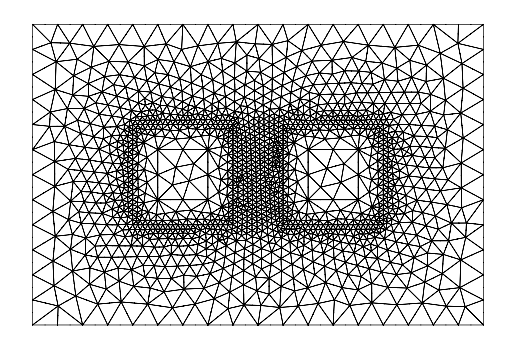

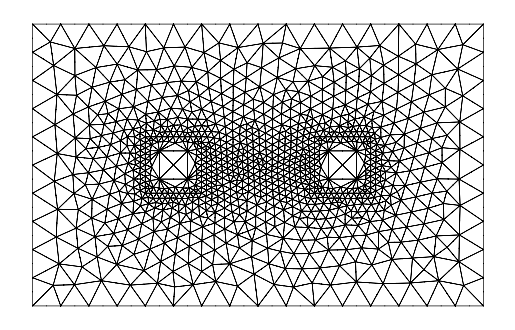

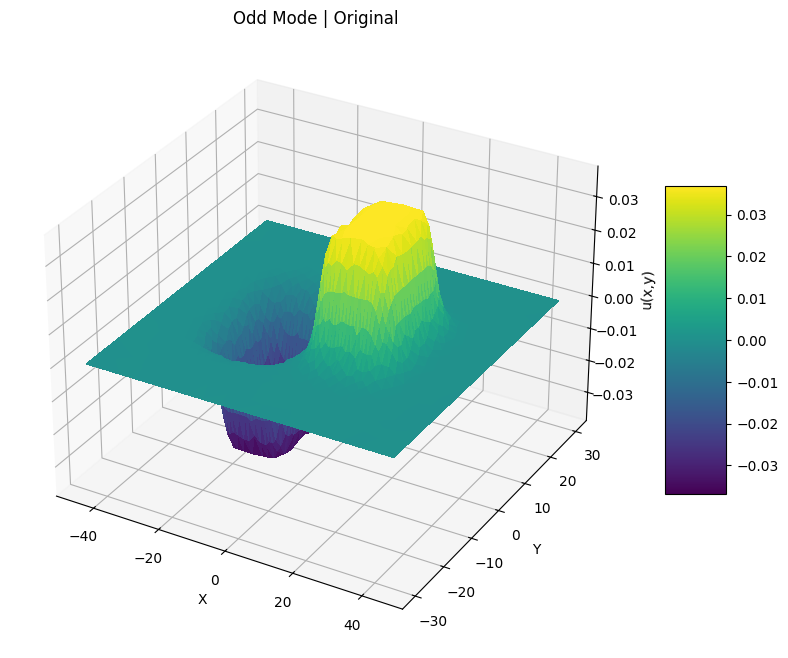

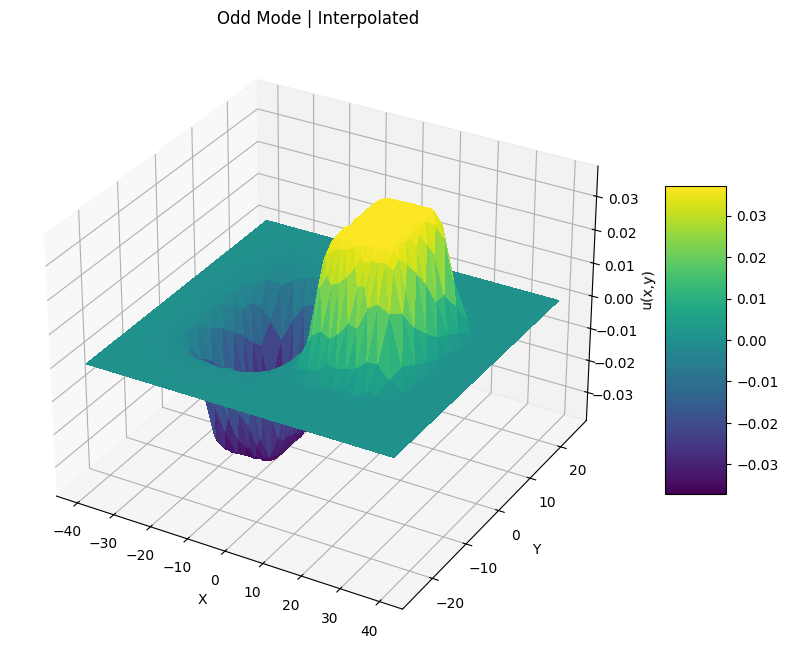

In [2]:
file_path1 = './../../2D/allplots/square20sep10num100/results.pkl'
file_path2 = './../../2D/allplots/square10sep20num100/results.pkl'

with open(file_path1, 'rb') as f:
    pickled_obj= pickle.load(f)
    femsystem1:FEMSystem = pickled_obj["femsystem"]
    femsystem1.saveFigsDir = None # Turn OFF saving plots
    u_even1,u_odd1  = pickled_obj["u_even"],pickled_obj["u_odd"]
    u_even_interior1,u_odd_interior1 = u_even1[femsystem1.interior_dofs],u_odd1[femsystem1.interior_dofs]
    theta_at_dofs1 = pickled_obj["theta_at_dofs"]

with open(file_path2, 'rb') as f:
    pickled_obj= pickle.load(f)
    femsystem2:FEMSystem = pickled_obj["femsystem"]
    femsystem2.saveFigsDir = None # Turn OFF saving plots


# Do the interpolation to the 2nd mesh:
u_even2 = interpolate_between_meshes(femsystem1,femsystem2,u_even1)
u_odd2 = interpolate_between_meshes(femsystem1,femsystem2,u_odd1)
u_even_interior2,u_odd_interior2 = u_even2[femsystem2.interior_dofs],u_odd2[femsystem2.interior_dofs]


# Plot: 
ax1 = femsystem1.mesh.draw()
ax2 = femsystem2.mesh.draw()

femsystem1.plot_at_interior_2d_in3d(u_odd_interior1,plot_title="Odd Mode | Original ")
femsystem2.plot_at_interior_2d_in3d(u_odd_interior2,plot_title="Odd Mode | Interpolated")

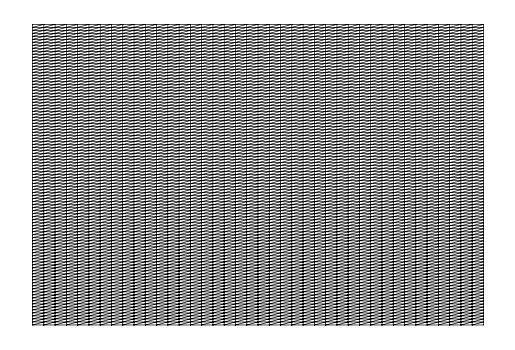

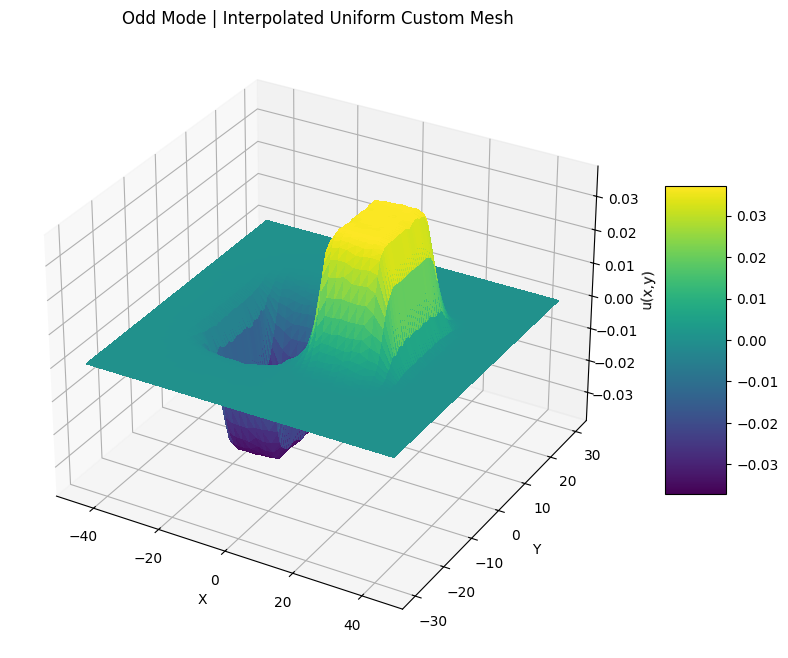

In [3]:
sys.path.append('../../RabiLondon')
from RabiLondonSystem import RabiLondonSystem

dims = RabiLondonSystem.mesh_dimensions(femsystem1)
newMesh = RabiLondonSystem.generate_mesh_rabilondon(dims[0],40,dims[1],100)
femsystem3 = FEMSystem(newMesh,femsystem1.element,femsystem1.intorder)
ax3 = femsystem3.mesh.draw()


u_even3 = interpolate_between_meshes(femsystem1,femsystem3,u_even1)
u_odd3 = interpolate_between_meshes(femsystem1,femsystem3,u_odd1)
u_even_interior3,u_odd_interior3 = u_even3[femsystem3.interior_dofs],u_odd3[femsystem3.interior_dofs]

femsystem3.plot_at_interior_2d_in3d(u_odd_interior3,plot_title="Odd Mode | Interpolated Uniform Custom Mesh")